<a href="https://colab.research.google.com/github/thisisShreya/part-3-nlp-sequence-modeling/blob/main/notebook3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Extracted
CSV File: /content/dataset/part_3_nlp_sequence_modeling/customer_support_text_classification.csv

First 5 Rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset Shape:
(1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype=

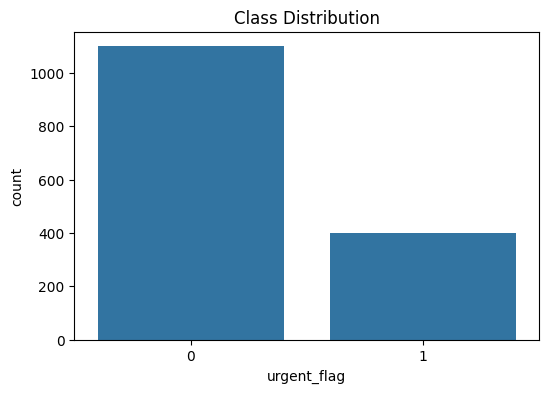


Cleaned Text Samples:
0    tkt00001
1    tkt00002
2    tkt00003
3    tkt00004
4    tkt00005
Name: ticket_id, dtype: object

TF-IDF Shape:
(1200, 1200)

Baseline Model Results:

              precision    recall  f1-score   support

           0       0.71      1.00      0.83       212
           1       0.00      0.00      0.00        88

    accuracy                           0.71       300
   macro avg       0.35      0.50      0.41       300
weighted avg       0.50      0.71      0.59       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


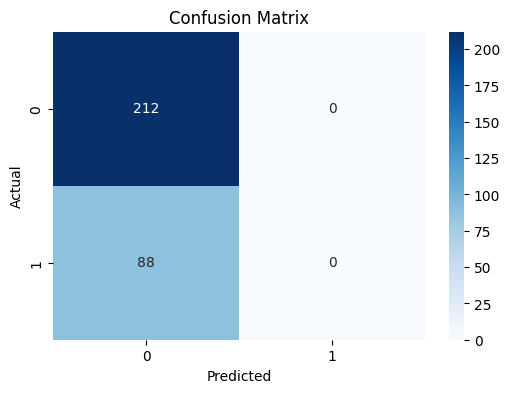

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7188 - loss: 0.5998 - val_accuracy: 0.7333 - val_loss: 0.5843
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7417 - loss: 0.5704 - val_accuracy: 0.7333 - val_loss: 0.5819
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7417 - loss: 0.5744 - val_accuracy: 0.7333 - val_loss: 0.5803
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7067 - loss: 0.6056

LSTM Test Accuracy: 0.7066666483879089


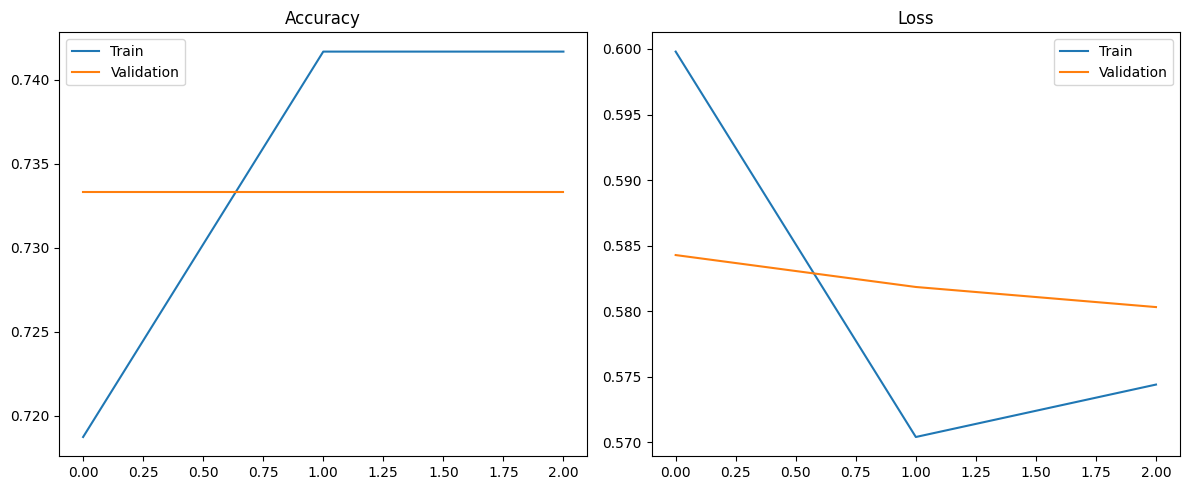


Sample Predictions:

Text: tkt01117
Predicted: 0
--------------------------------------------------
Text: tkt01369
Predicted: 0
--------------------------------------------------
Text: tkt00423
Predicted: 0
--------------------------------------------------
Text: tkt00414
Predicted: 0
--------------------------------------------------
Text: tkt00452
Predicted: 0
--------------------------------------------------


In [1]:
# =========================
# IMPORT LIBRARIES
# =========================

import os
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# EXTRACT ZIP FILE
# =========================

zip_path = '/content/part_3_nlp_sequence_modeling-20260517T152845Z-3-001.zip'

extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted")

# =========================
# FIND CSV FILE
# =========================

csv_file = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)

print("CSV File:", csv_file)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv(csv_file)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# =========================
# DETECT TEXT COLUMN
# =========================

text_col = None

for col in df.columns:
    if df[col].dtype == 'object':
        text_col = col
        break

# =========================
# DETECT TARGET COLUMN
# =========================

target_col = df.columns[-1]

print("\nText Column:", text_col)
print("Target Column:", target_col)

# =========================
# SAMPLE TEXT RECORDS
# =========================

print("\nSample Text:")
print(df[text_col].head())

# =========================
# TEXT LENGTH
# =========================

df['text_length'] = df[text_col].astype(str).apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())

# =========================
# CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x=df[target_col])

plt.title("Class Distribution")

plt.show()

# =========================
# TEXT PREPROCESSING
# =========================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    return text

df[text_col] = df[text_col].apply(clean_text)

print("\nCleaned Text Samples:")
print(df[text_col].head())

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col],
    df[target_col],
    test_size=0.2,
    random_state=42
)

# =========================
# TF-IDF VECTORIZATION
# =========================

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF Shape:")
print(X_train_tfidf.shape)

# =========================
# BASELINE MODEL
# =========================

baseline_model = LogisticRegression()

baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)

print("\nBaseline Model Results:\n")

print(classification_report(y_test, baseline_predictions))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================
# TOKENIZER SEQUENCES
# =========================

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df[text_col])

X_sequences = tokenizer.texts_to_sequences(df[text_col])

# =========================
# PADDING
# =========================

max_length = 100

X_padded = pad_sequences(
    X_sequences,
    maxlen=max_length,
    padding='post'
)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_padded,
    df[target_col],
    test_size=0.2,
    random_state=42
)

# =========================
# LSTM MODEL
# =========================

lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000,
              output_dim=64,
              input_length=max_length)
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(1, activation='sigmoid'))

# =========================
# COMPILE MODEL
# =========================

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN MODEL
# =========================

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

# =========================
# EVALUATION
# =========================

loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("\nLSTM Test Accuracy:", accuracy)

# =========================
# ACCURACY & LOSS CURVES
# =========================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')

plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')

plt.legend(['Train','Validation'])

plt.tight_layout()

plt.show()

# =========================
# SAMPLE PREDICTIONS
# =========================

sample_texts = X_test.iloc[:5]

sample_vectors = vectorizer.transform(sample_texts)

sample_preds = baseline_model.predict(sample_vectors)

print("\nSample Predictions:\n")

for text, pred in zip(sample_texts, sample_preds):

    print("Text:", text[:100])

    print("Predicted:", pred)

    print("-"*50)